In [1]:
# Import libraries
import matplotlib.pyplot as plt
import seaborn as sns
import tifffile as tiff
import numpy as np
from scipy import stats
import skimage as sk
from scipy import ndimage

In [2]:
img_happycell = tiff.imread("images/happy_cell_noise.tif")

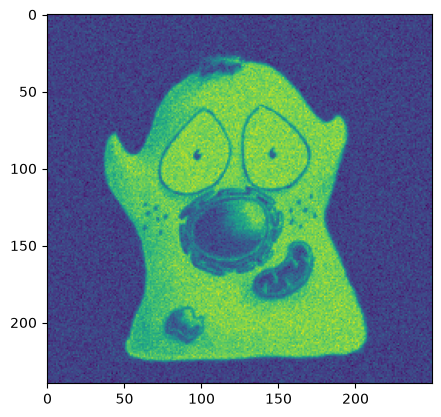

In [4]:
_ = plt.imshow(img_happycell)

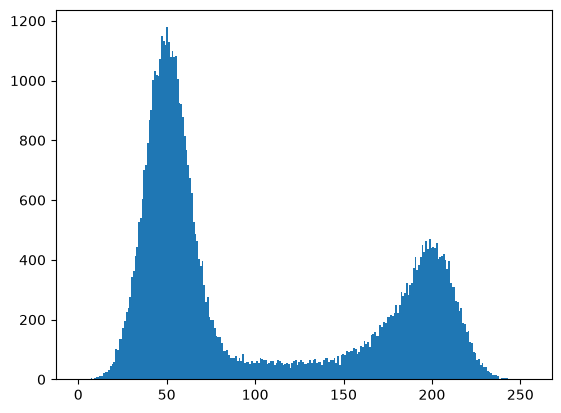

In [6]:
_ = plt.hist(img_happycell.ravel(), bins=256)

In [7]:
mask_happycell = img_happycell > 120

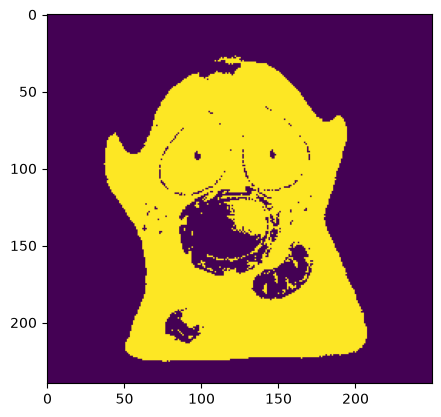

In [8]:
_ = plt.imshow(mask_happycell)

In [9]:
tresh_otsu = sk.filters.threshold_otsu(img_happycell)
print(tresh_otsu)

121


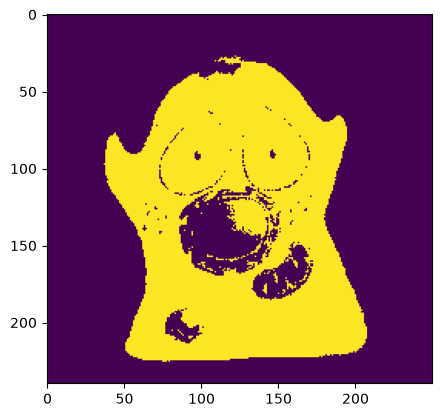

In [11]:
mask_happycell_otsu = img_happycell > tresh_otsu
_ = plt.imshow(mask_happycell_otsu)

In [12]:
# let's load another image
img_nuclei = tiff.imread("images/KTR_t0.tif")[0,:,:]

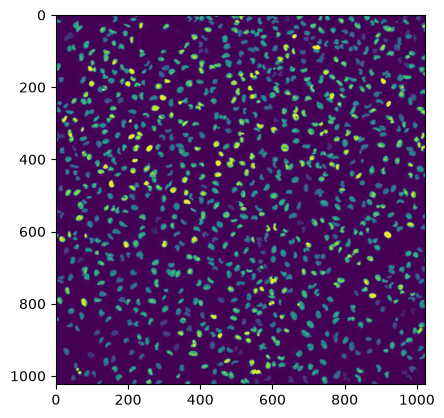

In [15]:
_ = plt.imshow(img_nuclei)

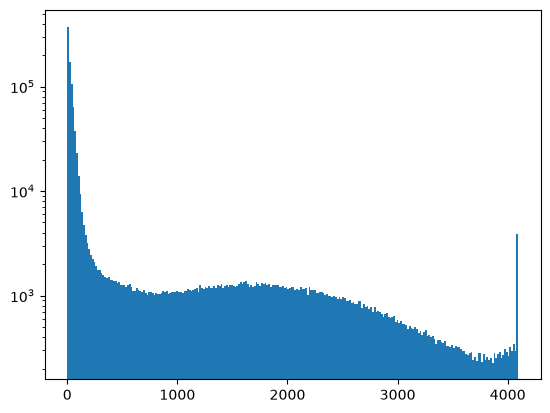

In [18]:
_ = plt.hist(img_nuclei.ravel(), bins=256)
plt.yscale("log")

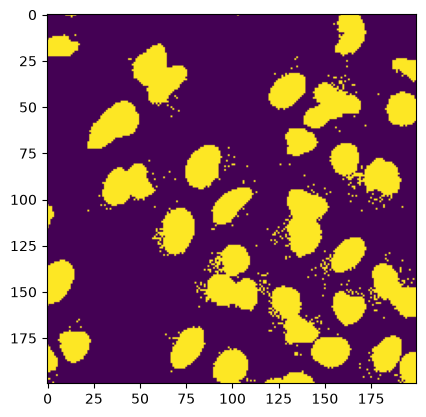

In [20]:
thresh_triangle = sk.filters.threshold_triangle(img_nuclei)
mask_nuclei = img_nuclei > thresh_triangle
_ = plt.imshow(mask_nuclei[0:200,0:200])

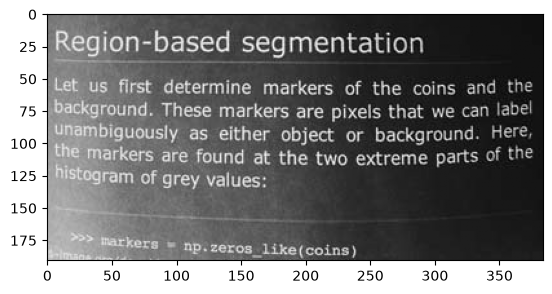

In [27]:
img_page = tiff.imread("images/page_original.tif")
img_page_inverted = np.invert(img_page)
_ = plt.imshow(img_page_inverted, cmap="gray")

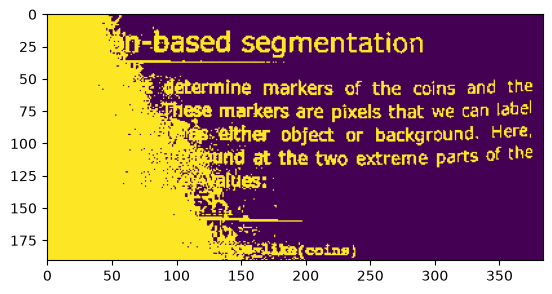

In [28]:
thresh_otsu_page = sk.filters.threshold_otsu(img_page_inverted)
_ = plt.imshow(img_page_inverted > thresh_otsu_page)

In [32]:
thresh_local = \
    sk.filters.threshold_local(
        img_page_inverted,
        block_size=35,
        offset=-10
    )
print(thresh_local)

[[130.56708693 130.63162864 130.75557298 ...  26.01988988  26.01392393
   26.01113931]
 [130.70447212 130.77211822 130.90207039 ...  26.02042314  26.014398
   26.01158297]
 [130.97806309 131.05212856 131.19449961 ...  26.02156593  26.01541334
   26.01253285]
 ...
 [205.24285372 205.16326338 205.01270429 ...  38.73896761  38.73150222
   38.7281811 ]
 [205.53652348 205.45706427 205.30698982 ...  38.86882487  38.86288083
   38.86034669]
 [205.68176852 205.60241999 205.45268039 ...  38.93474521  38.92956489
   38.92742578]]


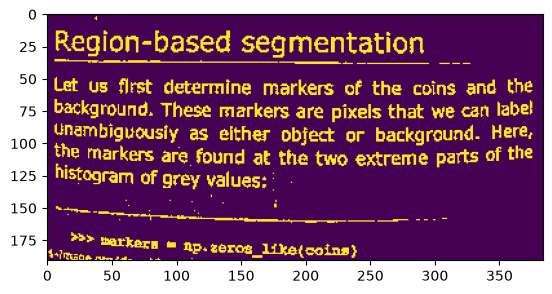

In [33]:
mask_page = img_page_inverted > thresh_local
_ = plt.imshow(mask_page)

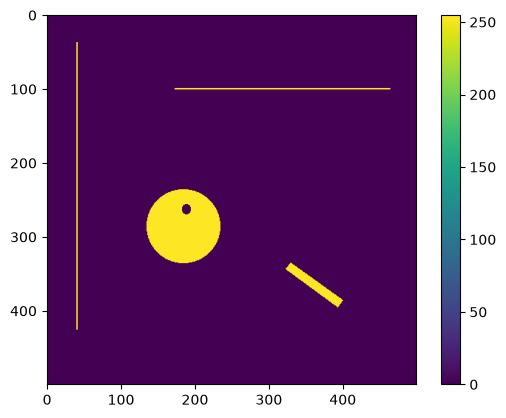

In [34]:
img_pika = tiff.imread("images/pikachu.tif")
_ = plt.imshow(img_pika)
_ = plt.colorbar()

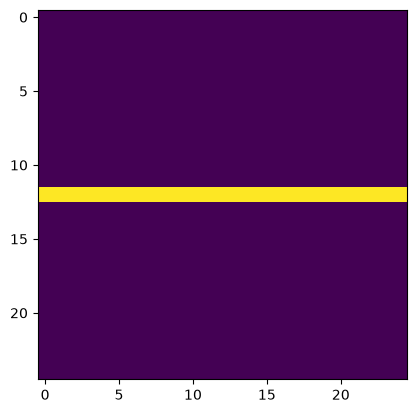

In [37]:
kernel_h = np.zeros((25,25))
kernel_h[12,:] = 1
kernel_h = kernel_h / np.sum(kernel_h)
_ = plt.imshow(kernel_h)

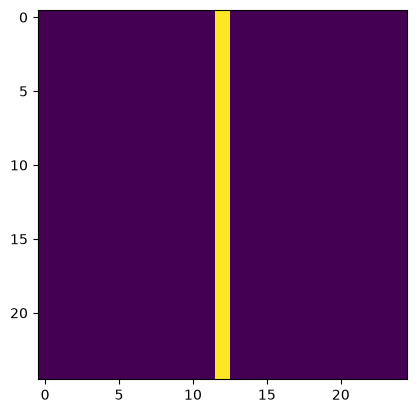

In [38]:
kernel_v = np.zeros((25,25))
kernel_v[:,12] = 1
kernel_v = kernel_v / np.sum(kernel_v)
_ = plt.imshow(kernel_v)

In [40]:
img_pika_h = ndimage.convolve(img_pika, kernel_h)
img_pika_v = ndimage.convolve(img_pika, kernel_v)

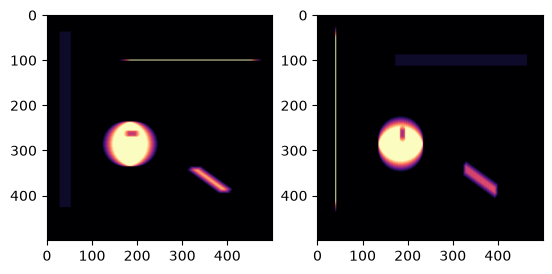

In [42]:
fig, axs = plt.subplots(1,2)
axs[0].imshow(img_pika_h, cmap='magma')
axs[1].imshow(img_pika_v, cmap='magma')

In [44]:
kernel_disk = sk.morphology.disk(15)
kernel_disk = kernel_disk / np.sum(kernel_disk)
# _ = plt.imshow(kernel_disk)

In [45]:
kernel_laplacian = np.array(
    [[0, -1, 0],
     [-1, 4, -1],
     [0, -1, 0]])

In [46]:
img_pika_disk = ndimage.convolve(
    img_pika.astype(np.float32),
    kernel_disk.astype(np.float32)
)
img_pika_edge = ndimage.convolve(
    img_pika.astype(np.float32),
    kernel_laplacian.astype(np.float32)
)
minmaxval1 = np.max(np.abs(img_pika_disk))


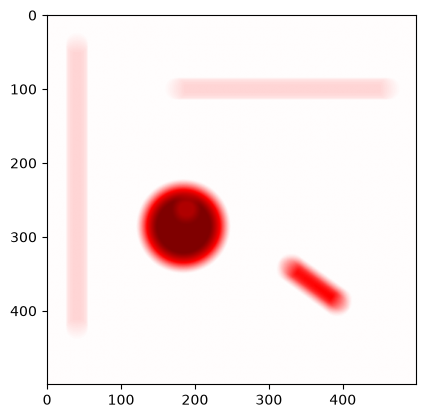

In [51]:
 _ = plt.imshow(img_pika_disk, cmap="seismic", vmin=-minmaxval1, vmax=minmaxval1)

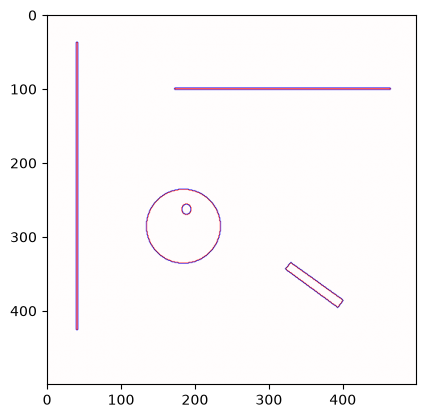

In [50]:
minmaxval2 = np.max(np.abs(img_pika_edge))
_ = plt.imshow(img_pika_edge, cmap="seismic", vmin=-minmaxval2, vmax=minmaxval2)

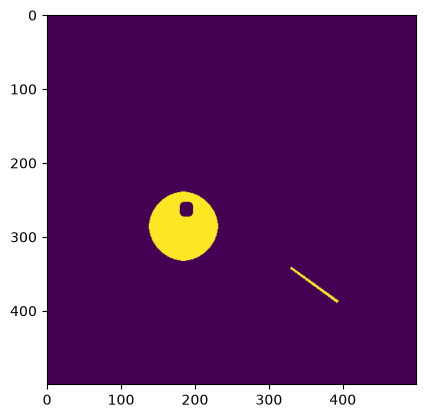

In [53]:
img_pika_eroded = sk.morphology.erosion(
    img_pika,
    footprint = np.ones((7,7))
)
_ = plt.imshow(img_pika_eroded)

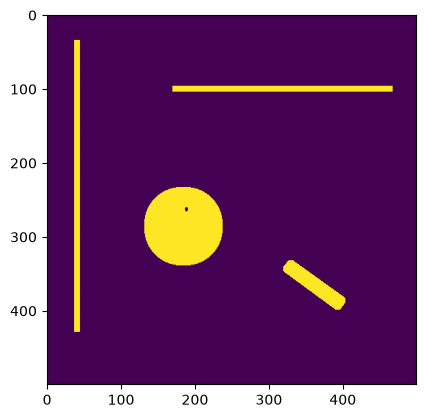

In [54]:
img_pika_dilation = sk.morphology.dilation(
    img_pika,
    footprint = np.ones((7,7))
)
_ = plt.imshow(img_pika_dilation)

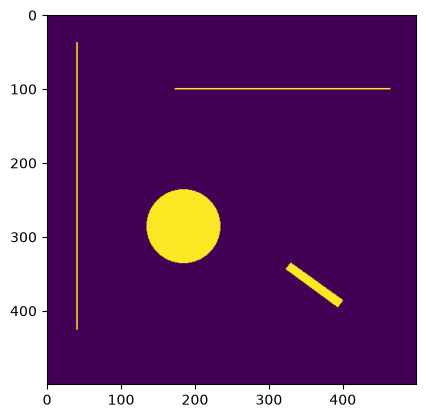

In [56]:
img_pika_closed = sk.morphology.closing(
    img_pika,
    footprint = np.ones((15,15))
)
_ = plt.imshow(img_pika_closed)

In [57]:
img_nuclei = tiff.imread("images/KTR_t0.tif")[0,:,:]
img_KTR    = tiff.imread("images/KTR_t0.tif")[2,:,:]

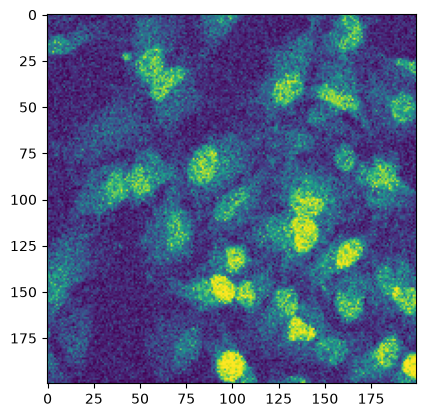

In [59]:
_ = plt.imshow(img_KTR[0:200,0:200])

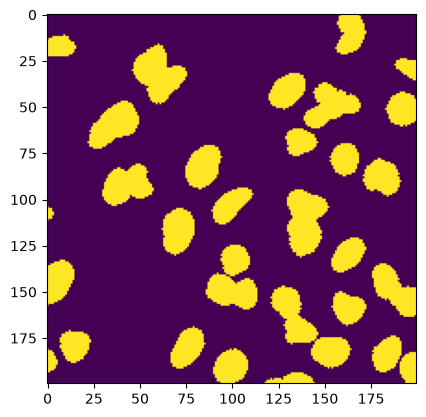

In [60]:
thresh_triangle = sk.filters.threshold_triangle(img_nuclei)
mask_nuclei = img_nuclei > thresh_triangle
mask_nuclei_clean = sk.morphology.opening(
    mask_nuclei,
    footprint = sk.morphology.disk(3)
)
_=plt.imshow(mask_nuclei_clean[0:200,0:200])

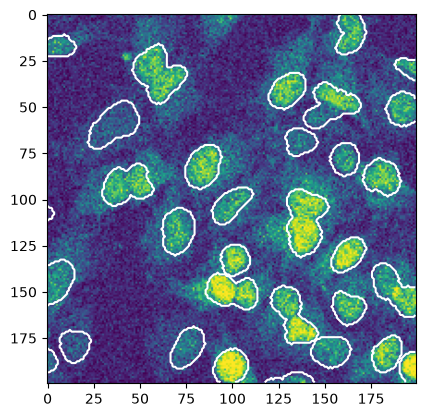

In [61]:
plt.imshow(img_KTR[0:200,0:200])
plt.contour(mask_nuclei_clean[0:200, 0:200], colors="w")

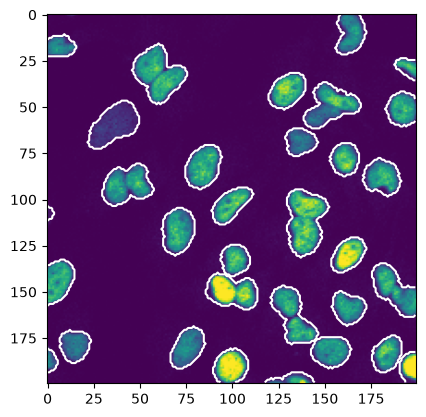

In [62]:
plt.imshow(img_nuclei[0:200,0:200])
plt.contour(mask_nuclei_clean[0:200, 0:200], colors="w")

In [63]:
the_mode1 = stats.mode(img_KTR.ravel())[0]
print(the_mode1)
the_mode2 = np.bincount(img_KTR.ravel()).argmax()
print(the_mode2)

480
480


(array([3.19180e+04, 0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00,
        0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00, 9.90000e+01,
        8.42830e+04, 0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00,
        0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00, 1.26000e+02,
        1.21750e+05, 0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00,
        0.00000e+00, 0.00000e+00, 0.00000e+00, 1.35000e+02, 0.00000e+00,
        1.29313e+05, 0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00,
        0.00000e+00, 0.00000e+00, 0.00000e+00, 1.36000e+02, 0.00000e+00,
        1.17513e+05, 0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00,
        0.00000e+00, 0.00000e+00, 9.00000e+00, 8.70000e+01, 0.00000e+00,
        9.77520e+04, 0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00,
        0.00000e+00, 0.00000e+00, 6.10000e+01, 0.00000e+00, 0.00000e+00,
        7.88900e+04, 0.00000e+00, 0.00000e+00, 0.00000e+00, 2.40000e+01,
        0.00000e+00, 0.00000e+00, 6.50000e+01, 0.00

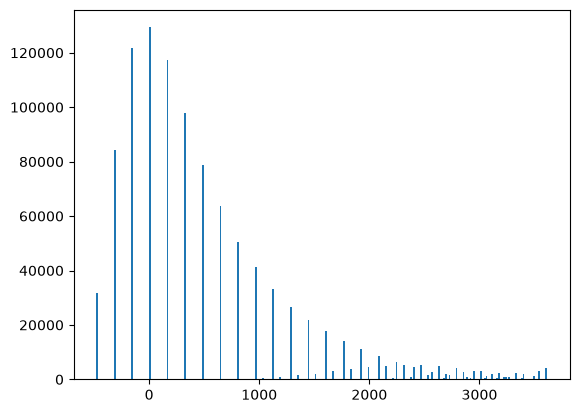

In [66]:
img_KTR_corr = img_KTR.astype(float)-the_mode1
plt.hist(img_KTR_corr.ravel(), bins=256)

In [67]:
np.mean(img_KTR[mask_nuclei])

np.float64(1997.0859060251207)

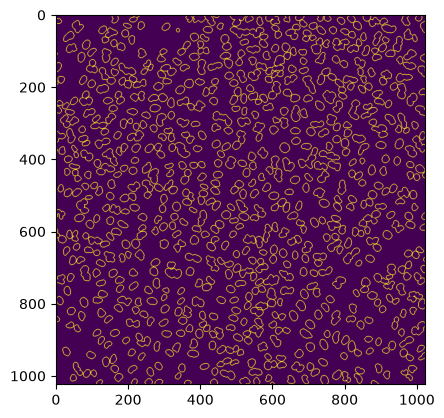

In [68]:
mask_nuclei_clean_dilated = sk.morphology.dilation(
    mask_nuclei_clean,
    sk.morphology.disk(2))
mask_cytoplasm = mask_nuclei_clean_dilated & ~mask_nuclei_clean
plt.imshow(mask_cytoplasm)

In [69]:
print(np.mean(img_KTR[mask_nuclei]))
print(np.mean(img_KTR[mask_cytoplasm]))

1997.0859060251207
1000.8858317304406


In [70]:
np.mean(img_KTR[mask_cytoplasm]) / np.mean(img_KTR[mask_nuclei]) 

np.float64(0.5011731486917071)

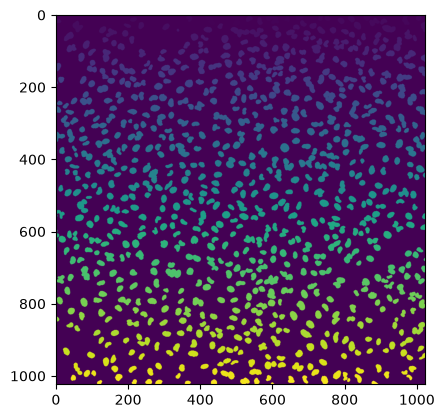

In [71]:
mask_nuclei_labeled = sk.measure.label(mask_nuclei_clean, 
                                       connectivity = 1)
_ = plt.imshow(mask_nuclei_labeled)

In [72]:
print(mask_nuclei_labeled[0:20, 0:20])

[[ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0 23  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0 23 23 23 23 23 23 23 23 23  0  0  0  0  0  0  0  0]
 [ 0 23 23 23 23 23 23 23 23 23 23 23  0  0  0  0  0  0  0  0]
 [23 23 23 23 23 23 23 23 23 23 23 23 23  0  0  0  0  0  0  0]
 [23 23 23 23 23 23 23 23 23 23 23 23 23 23 23  0  0  0

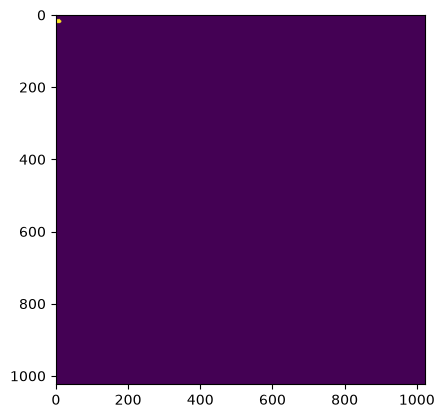

In [73]:
plt.imshow(mask_nuclei_labeled==23)

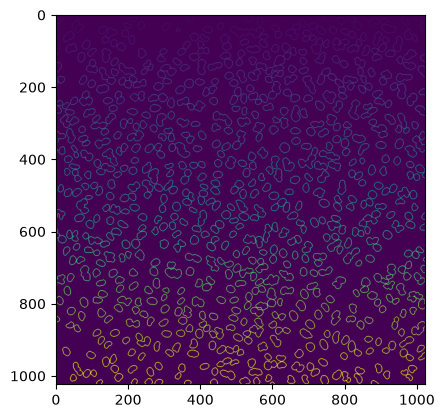

In [74]:
mask_cytoplasm_labeled = sk.morphology.dilation(mask_nuclei_labeled,
                                                sk.morphology.disk(2))
mask_cytoplasm_labeled[mask_nuclei_clean] = 0
plt.imshow(mask_cytoplasm_labeled)

In [75]:
ratios = []
for idx in range(1, np.max(mask_cytoplasm_labeled)):
    ratios.append(
        np.mean(img_KTR[mask_cytoplasm_labeled==idx]) / 
        np.mean(img_KTR[mask_nuclei_labeled==idx])
    )
print(ratios[0:10])

[np.float64(0.5376960963574011), np.float64(0.5567022853975222), np.float64(0.5620778235060323), np.float64(0.5349040191788493), np.float64(0.5941152087702692), np.float64(0.5287349711068803), np.float64(0.5271857178227263), np.float64(0.8759388038942976), np.float64(0.4086213144636655), np.float64(0.5080422794117647)]


(array([ 14., 187., 339., 161.,  53.,  24.,  14.,   2.,   0.,   1.]),
 array([0.24512166, 0.3429489 , 0.44077614, 0.53860338, 0.63643062,
        0.73425786, 0.8320851 , 0.92991234, 1.02773958, 1.12556682,
        1.22339406]),
 <BarContainer object of 10 artists>)

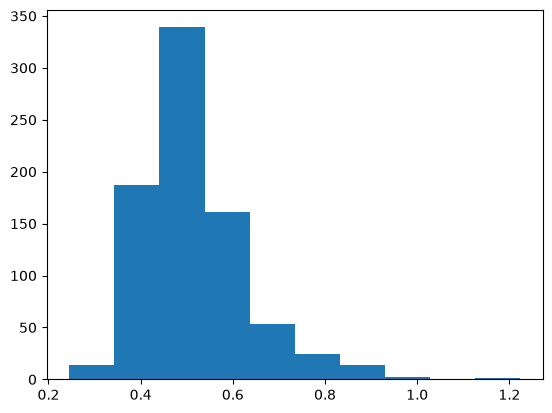

In [76]:
plt.hist(ratios)